<a href="https://colab.research.google.com/github/waymaker55/ehijeleabhulimhen.github.io./blob/main/finalcodeforsubmittion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/content/drive/MyDrive/Data_Mining/Tourism_Data_Combined_2010-2024.csv
Data Loaded: (180, 5)

--- Step 2: Feature Engineering ---
Target Distribution:
Demand_Level
Low         42
Shoulder    42
High        42
Peak        42
Name: count, dtype: int64

>>> ACTUAL BIN RANGES FOR TABLE 3.1 <<<
                 min      max
Demand_Level                 
Low            20388   678590
Shoulder      689782   804221
High          807716   908298
Peak          908839  1035719


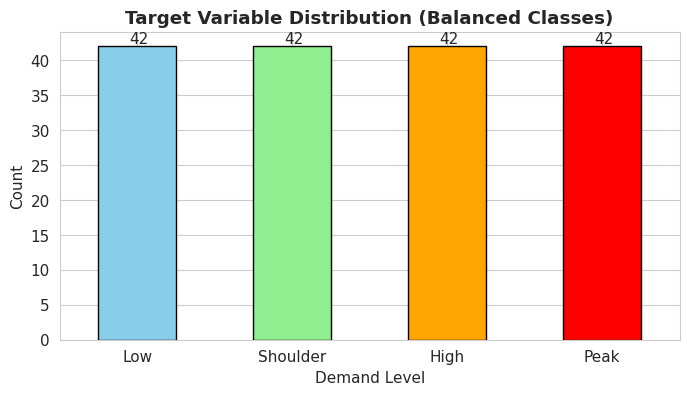


--- Step 3: Exploratory Data Analysis ---


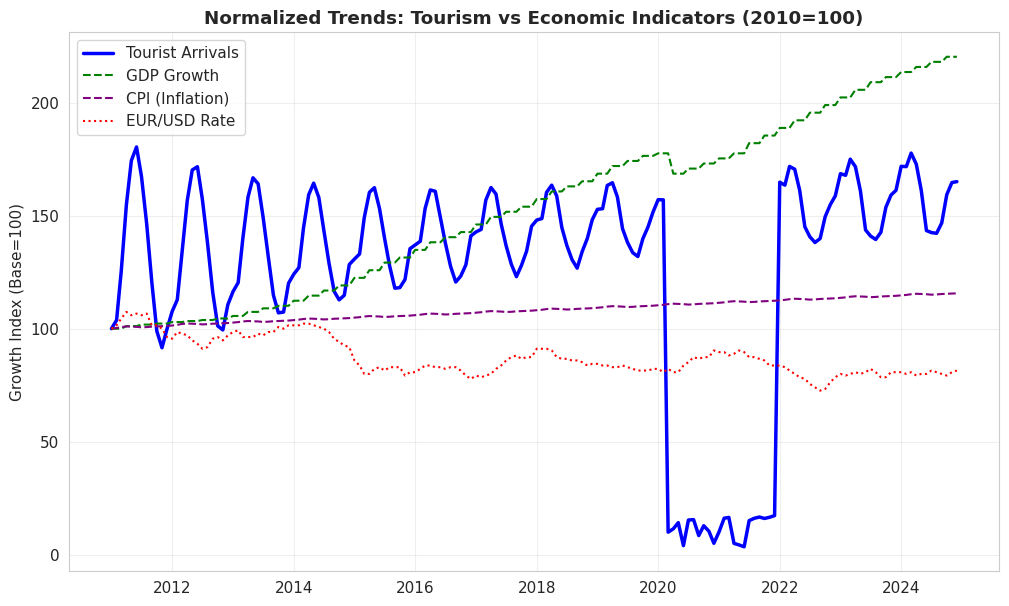

/tmp/ipython-input-3327435341.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Month_Name', y='Arrivals', data=df, order=months_order, palette="Blues")


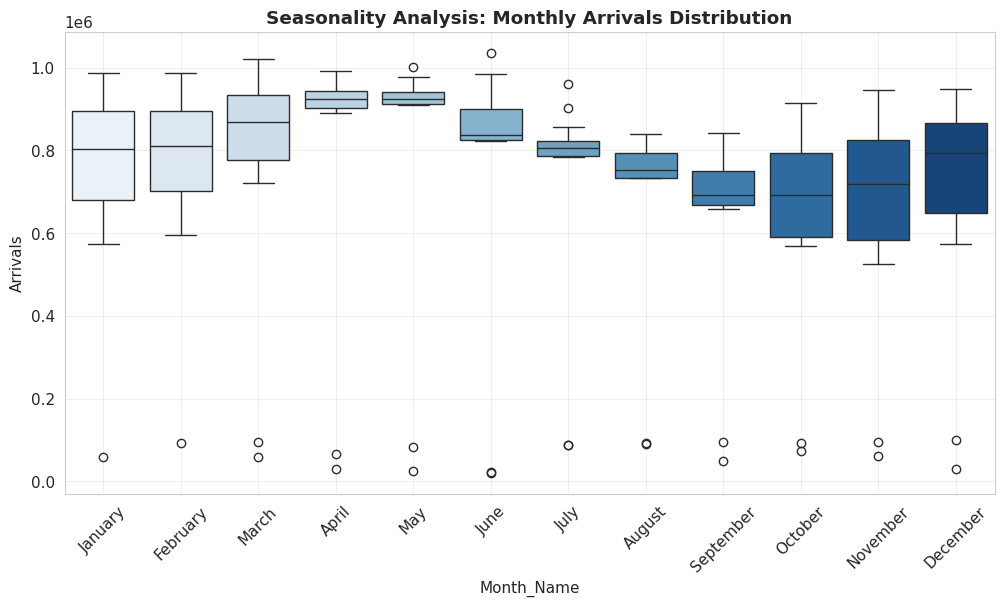


--- Step 4: Model Training ---

>>> SVC Classification Report (Scaled):
              precision    recall  f1-score   support

         Low       0.00      0.00      0.00        12
    Shoulder       0.00      0.00      0.00         0
        High       0.78      0.37      0.50        19
        Peak       0.25      1.00      0.40         3

    accuracy                           0.29        34
   macro avg       0.26      0.34      0.23        34
weighted avg       0.46      0.29      0.31        34


>>> Random Forest Classification Report:
              precision    recall  f1-score   support

         Low       0.58      0.58      0.58        12
    Shoulder       0.00      0.00      0.00         0
        High       1.00      0.47      0.64        19
        Peak       0.38      1.00      0.55         3

    accuracy                           0.56        34
   macro avg       0.49      0.51      0.44        34
weighted avg       0.80      0.56      0.61        34


>>> XGBoost Cl

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

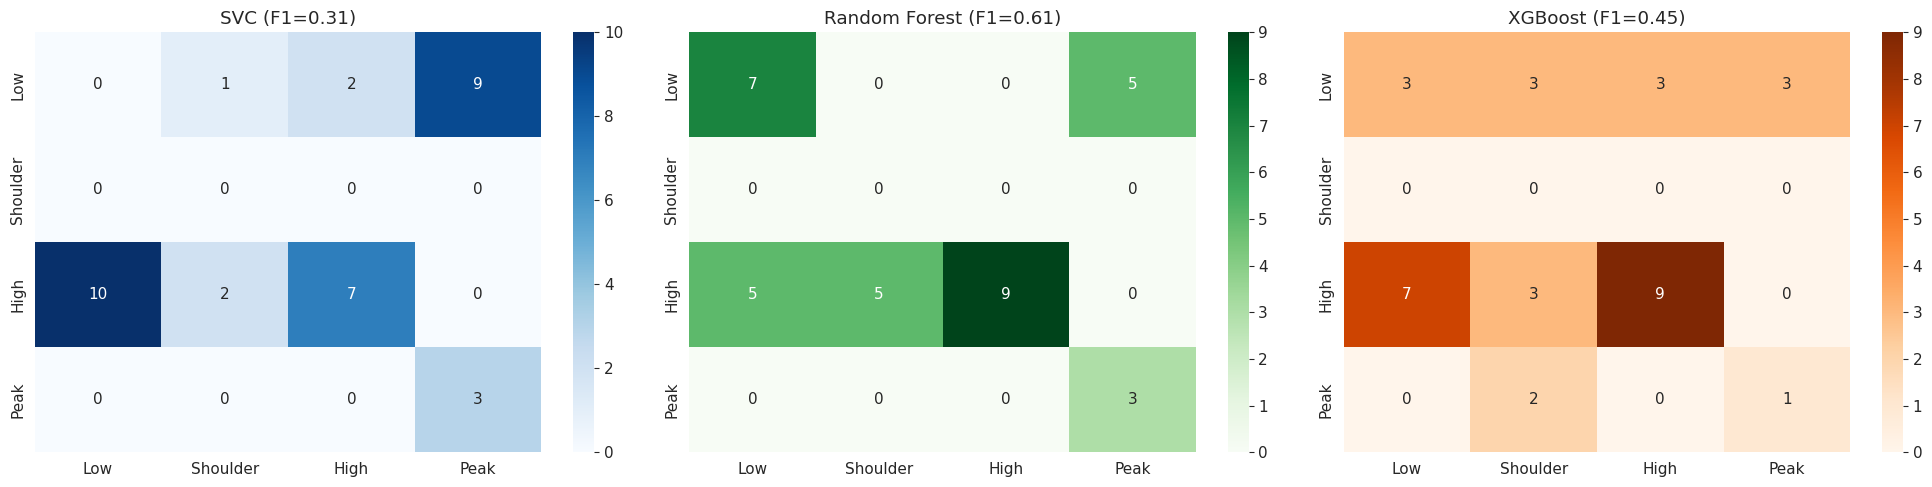


🏆 Best Model: RF


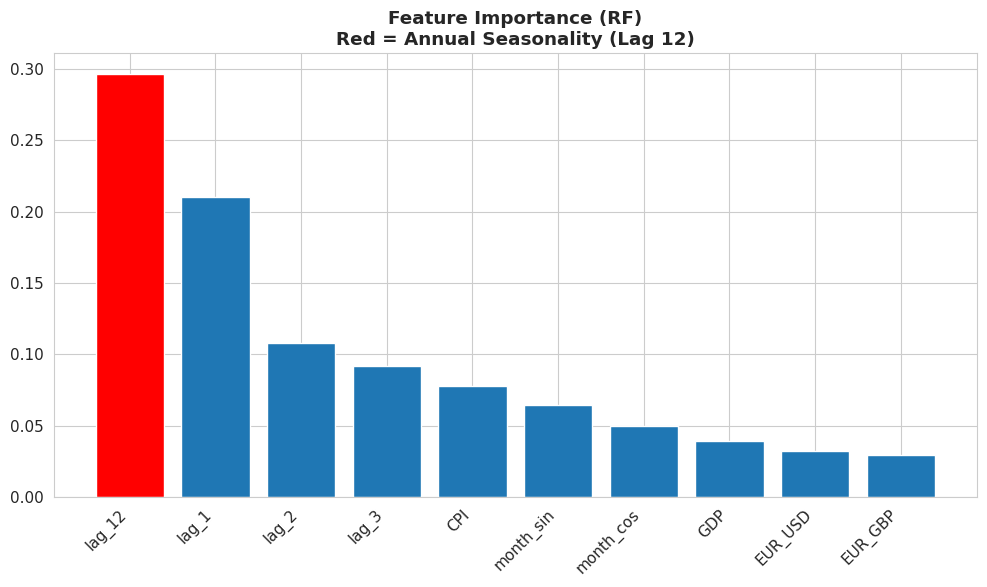


--- Step 6: 2025 Forecast ---
         Date  Forecast
0  2025-01-01       Low
1  2025-02-01       Low
2  2025-03-01       Low
3  2025-04-01      Peak
4  2025-05-01      Peak
5  2025-06-01      High
6  2025-07-01  Shoulder
7  2025-08-01  Shoulder
8  2025-09-01      High
9  2025-10-01      High
10 2025-11-01      High
11 2025-12-01       Low


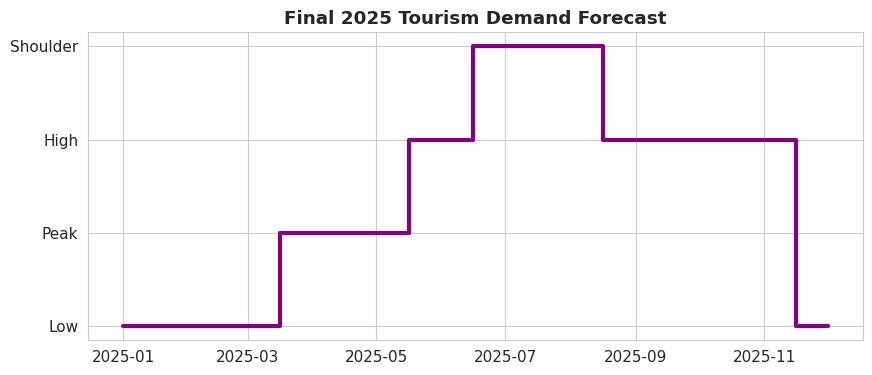

In [1]:
# ==============================================================================
# Libaries
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Style settings for academic charts
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 11, 'figure.titlesize': 14})

# ------------------------------------------------------------------------------
# 1. DATA LOADING
# ------------------------------------------------------------------------------
print("/content/drive/MyDrive/Data_Mining/Tourism_Data_Combined_2010-2024.csv")
file_path = '/content/drive/MyDrive/Data_Mining/Tourism_Data_Combined_2010-2024.csv'
df = pd.read_csv(file_path)
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

# Handle Missing Values
df.ffill(inplace=True)
print(f"Data Loaded: {df.shape}")

# ------------------------------------------------------------------------------
# 2. FEATURE ENGINEERING (Lags 1, 2, 3, 12)
# ------------------------------------------------------------------------------
print("\n--- Step 2: Feature Engineering ---")

# Seasonality
df['month_sin'] = np.sin(2 * np.pi * df.index.month / 12)
df['month_cos'] = np.cos(2 * np.pi * df.index.month / 12)

# Lags (Strictly per feedback: 1, 2, 3, and 12)
# Lag 12 is CRITICAL for annual cycles.
for lag in [1, 2, 3, 12]:
    df[f'lag_{lag}'] = df['Arrivals'].shift(lag)

df.dropna(inplace=True)

# Target Labels (Balanced Buckets)
labels = ['Low', 'Shoulder', 'High', 'Peak']
df['Demand_Level'] = pd.qcut(df['Arrivals'], q=4, labels=labels)

print("Target Distribution:")
print(df['Demand_Level'].value_counts())

# --- P
print("\n>>> ACTUAL BIN RANGES FOR TABLE 3.1 <<<")
print(df.groupby('Demand_Level', observed=True)['Arrivals'].agg(['min', 'max']))


# --- CHART: Target Distribution
plt.figure(figsize=(8, 4))
ax = df['Demand_Level'].value_counts().loc[labels].plot(kind='bar', color=['skyblue', 'lightgreen', 'orange', 'red'], edgecolor='black')
plt.title('Target Variable Distribution (Balanced Classes)', fontweight='bold')
plt.xlabel('Demand Level')
plt.ylabel('Count')
plt.xticks(rotation=0)
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + 0.2, p.get_height() + 0.5))
plt.show()

# ------------------------------------------------------------------------------
# 3. UNIFIED EDA CHART (Normalized Index)
# ------------------------------------------------------------------------------
print("\n--- Step 3: Exploratory Data Analysis ---")

# Normalizing Data to start at 100 (Base 100 Index)
# This allows plotting GDP (40k) and Exch Rate (1.2) on the same chart.
df_norm = df[['Arrivals', 'GDP', 'CPI', 'EUR_USD']].copy()
df_norm = (df_norm / df_norm.iloc[0]) * 100

plt.figure(figsize=(12, 7))
plt.plot(df_norm.index, df_norm['Arrivals'], label='Tourist Arrivals', linewidth=2.5, color='blue')
plt.plot(df_norm.index, df_norm['GDP'], label='GDP Growth', linestyle='--', color='green')
plt.plot(df_norm.index, df_norm['CPI'], label='CPI (Inflation)', linestyle='--', color='purple')
plt.plot(df_norm.index, df_norm['EUR_USD'], label='EUR/USD Rate', linestyle=':', color='red')

plt.title('Normalized Trends: Tourism vs Economic Indicators (2010=100)', fontweight='bold')
plt.ylabel('Growth Index (Base=100)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- CHART: Seasonality Box Plot (Restored) ---
df['Month_Name'] = df.index.month_name()
months_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

plt.figure(figsize=(12, 6))
sns.boxplot(x='Month_Name', y='Arrivals', data=df, order=months_order, palette="Blues")
plt.title('Seasonality Analysis: Monthly Arrivals Distribution', fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

# ------------------------------------------------------------------------------
# 4. MODEL TRAINING & EVALUATION (Tables Restored)
# ------------------------------------------------------------------------------
print("\n--- Step 4: Model Training ---")

X = df.drop(['Arrivals', 'Demand_Level', 'Month_Name'], axis=1)
y = df['Demand_Level']

# Label Encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Chronological Split (No random shuffling for Time Series!)
split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y_encoded[:split], y_encoded[split:]

# 1. SVC (Scaled)
svc = Pipeline([('scaler', StandardScaler()), ('svc', SVC(kernel='rbf', probability=True))])
svc.fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)

# 2. Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# 3. XGBoost
xgb = XGBClassifier(n_estimators=200, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

# --- PRINT TABLES (Classification Reports) ---
print("\n>>> SVC Classification Report (Scaled):")
print(classification_report(y_test, y_pred_svc, target_names=labels))

print("\n>>> Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=labels))

print("\n>>> XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=labels))

# --- CHART: Confusion Matrices (All Models) ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_svc), annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=labels, yticklabels=labels)
axes[0].set_title(f'SVC (F1={f1_score(y_test, y_pred_svc, average="weighted"):.2f})')

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', ax=axes[1], xticklabels=labels, yticklabels=labels)
axes[1].set_title(f'Random Forest (F1={f1_score(y_test, y_pred_rf, average="weighted"):.2f})')

sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Oranges', ax=axes[2], xticklabels=labels, yticklabels=labels)
axes[2].set_title(f'XGBoost (F1={f1_score(y_test, y_pred_xgb, average="weighted"):.2f})')

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 5. FEATURE IMPORTANCE
# ------------------------------------------------------------------------------
# Selecting Best Model for Deep Dive
scores = {'SVC': f1_score(y_test, y_pred_svc, average='weighted'),
          'RF': f1_score(y_test, y_pred_rf, average='weighted'),
          'XGB': f1_score(y_test, y_pred_xgb, average='weighted')}
best_name = max(scores, key=scores.get)
print(f"\n🏆 Best Model: {best_name}")

if best_name != 'SVC':
    model = rf if best_name == 'RF' else xgb
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]

    plt.figure(figsize=(10, 6))
    # Highlight Lag 12 in Red to show Lecturer
    colors = ['red' if 'lag_12' in X.columns[i] else '#1f77b4' for i in indices]

    plt.bar(range(X.shape[1]), importances[indices], align="center", color=colors)
    plt.xticks(range(X.shape[1]), X.columns[indices], rotation=45, ha='right')
    plt.title(f'Feature Importance ({best_name})\nRed = Annual Seasonality (Lag 12)', fontweight='bold')
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------------------
# 6. 2025 FORECAST
# ------------------------------------------------------------------------------
print("\n--- Step 6: 2025 Forecast ---")

dates_2025 = pd.date_range(start='2025-01-01', end='2025-12-01', freq='MS')
history = df['Arrivals'].tolist()
predictions = []

# Using the mean of each class to "fill in" the future numbers
class_means = df.groupby('Demand_Level', observed=True)['Arrivals'].mean()

for i, date in enumerate(dates_2025):
    # Features
    month_sin = np.sin(2 * np.pi * date.month / 12)
    month_cos = np.cos(2 * np.pi * date.month / 12)

    # Lags:
    # lag_1 is the previous month (history[-1])
    # lag_12 is the same month last year (history[-12])
    # This ensures "Peak" months in 2024 push 2025 predictions up.
    feat = {
        'GDP': df['GDP'].iloc[-1], # Assuming constant
        'CPI': df['CPI'].iloc[-1],
        'EUR_USD': df['EUR_USD'].iloc[-1],
        'EUR_GBP': df['EUR_GBP'].iloc[-1],
        'month_sin': month_sin,
        'month_cos': month_cos,
        'lag_1': history[-1],
        'lag_2': history[-2],
        'lag_3': history[-3],
        'lag_12': history[-12]
    }

    row_df = pd.DataFrame([feat])[X_train.columns]

    # Predict
    pred_idx = xgb.predict(row_df)[0] if best_name == 'XGB' else rf.predict(row_df)[0]
    pred_label = le.inverse_transform([pred_idx])[0]
    predictions.append(pred_label)

    # Update History: Use the 'Class Mean' to feed next month
    # But weight it with Lag 12 to prevent "Low Loop"
    # Logic: 70% Last Year's Value + 30% Class Mean (Heuristic for stability)
    simulated_val = (history[-12] * 0.7) + (class_means[pred_label] * 0.3)
    history.append(simulated_val)

results_2025 = pd.DataFrame({'Date': dates_2025, 'Forecast': predictions})
print(results_2025)

# Plot Forecast Timeline
plt.figure(figsize=(10, 4))
plt.step(results_2025['Date'], results_2025['Forecast'], where='mid', color='purple', linewidth=3)
plt.title('Final 2025 Tourism Demand Forecast', fontweight='bold')
plt.grid(True)
plt.show()